# Análisis de inclinómetro SmartNode — La Palmera


## 0. Imports y configuración

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import tol_colors as tc

from sn_dagrd.inclinometer_io import (
    read_inclinometer_jsonl,
    sample_inclinometer_df,
    resample_inclinometer_df,
)

from sn_dagrd.drift_correction import (
    correct_sensor_angles_moving_df,
    correct_sensor_angles_ssa_df,
)

from sn_dagrd.inclinometer_kinematics import (
    compute_inclinometer_displacements,
    get_displacement_profile,
)

from sn_dagrd.inclinometer_plotting import (
    plot_angle_correction_over_time,
    plot_cumulative_displacement_profiles,
    plot_single_displacement_profile,
    plot_sensor_displacement_evolution,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # or "Computer Modern Roman", "cmr", "cmr10", 
    "mathtext.fontset": "cm",  # Use Computer Modern fonts for math
    "axes.formatter.use_mathtext": True,  # Use mathtext for axis labels
    "axes.unicode_minus": False,   # Use standard minus sign instead of a unicode character
})

## 1. Parámetros del análisis

Ajusta aquí los parámetros principales del análisis.

- `depths_m` debe estar en el mismo orden que los sensores declarados en `valid_sensors_inc`: `1a`, `2a`, ..., `15a`.
- Los sensores con valor `0` se excluyen del perfil.
- Los sensores superficiales `16a`, `17a`, `18a` no se incluyen si no están declarados en `valid_sensors_inc`.


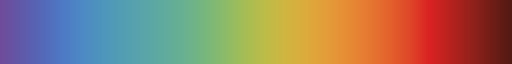

In [2]:
# ---------------------------------------------------------------------
# Rutas
# ---------------------------------------------------------------------
path2readings = Path("./data_smartnodes/santa_rita_1/raw_InclinometroSantaRita1.txt")
path2figures = Path("./figures_smartnodes/santa_rita_1")
path2figures.mkdir(exist_ok=True)


# ---------------------------------------------------------------------
# Información de estación
# ---------------------------------------------------------------------
station = {
    "name": "Santa Rita 1",
    "code": "SR-SN-01",
    "station_id": "SmartNode-SantaRita1",
}


# ---------------------------------------------------------------------
# Sensores del perfil inclinométrico
# ---------------------------------------------------------------------
valid_sensors_inc = {
    "1a": 1,
    "2a": 1,
    "3a": 1,
    "4a": 1,
    "5a": 1,
    "6a": 1,
    "7a": 1,
    "8a": 1,
    "9a": 1,
    "10a": 1,
    "11a": 1,
    "12a": 1,
    "13a": 1,
    "14a": 1,
    "15a": 1,
}


# ---------------------------------------------------------------------
# Profundidades explícitas de los sensores declarados
# Mismo orden que valid_sensors_inc: 1a, 2a, ..., 15a.
# ---------------------------------------------------------------------
depths_m = np.linspace(1.0, 15.0, num=15)


# ---------------------------------------------------------------------
# Orientación del eje local A del inclinómetro
# ---------------------------------------------------------------------
azimuth_deg = 30.0


# ---------------------------------------------------------------------
# Recorte temporal y submuestreo
# ---------------------------------------------------------------------
start_date = "2026-05-01"
sample_freq = "6h"   # toma un dato real cada 6h, sin suavizar


# ---------------------------------------------------------------------
# Parámetros de corrección de deriva
# ---------------------------------------------------------------------
correction_params = dict(
    window_time="1D",
    method="median",
    jump_threshold=10.0,
    min_jump_distance_time="1D",
    max_jump_gap=1,
    anchor_points=4,
)

# ---------------------------------------------------------------------
# Otros
# ---------------------------------------------------------------------
cmap = tc.colormaps["rainbow_PuBr"]
cmap

## 2. Lectura y submuestreo

`sample_inclinometer_df` toma una fila real por intervalo de tiempo.  
No calcula medias ni medianas, por tanto no suaviza la señal.


In [3]:
df_raw = read_inclinometer_jsonl(
    path=path2readings,
    sensor_type="BNO",
    drop_duplicate_rows=True,
)

df_raw = (
    df_raw
    .loc[df_raw["timestamp"] >= pd.Timestamp(start_date)]
    .reset_index(drop=True)
)

df_raw_6h = sample_inclinometer_df(
    df_raw,
    freq=sample_freq,
    how="first",
)

print("df_raw:", df_raw.shape)
print("df_raw_6h:", df_raw_6h.shape)

df_raw_6h.head()


df_raw: (21114, 14)
df_raw_6h: (1854, 14)


,line_no,estacion_id,timestamp,sensor_id,qr,qi,qj,qk,uptime_s,heap,rssi,roll_deg,pitch_deg,yaw_deg
0,343,SmartNode-SantaRita1,2026-05-01 00:16:19,10a,19996.0,10034.0,9731.0,10000.0,21616,103768,-47,0.390048,-3.082967,-0.010496
1,355,SmartNode-SantaRita1,2026-05-01 06:16:20,10a,19996.0,10032.0,9729.0,9998.0,43216,103780,-44,0.367730,-3.105808,-0.032897
2,367,SmartNode-SantaRita1,2026-05-01 12:16:20,10a,19996.0,10033.0,9729.0,10000.0,64817,101984,-39,0.378580,-3.105879,-0.010264
3,379,SmartNode-SantaRita1,2026-05-01 18:16:21,10a,19996.0,10034.0,9733.0,10000.0,16,103796,-40,0.390044,-3.060056,-0.010418
4,391,SmartNode-SantaRita1,2026-05-02 00:16:22,10a,19996.0,10036.0,9733.0,10000.0,21616,103784,-47,0.412988,-3.060052,-0.011031


## 3. Revisión rápida de disponibilidad por sensor

In [4]:
availability = (
    df_raw_6h
    .assign(has_quaternion=lambda d: d[["qr", "qi", "qj", "qk"]].notna().all(axis=1))
    .groupby("sensor_id")
    .agg(
        n_rows=("timestamp", "size"),
        n_valid_quaternion=("has_quaternion", "sum"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
    )
    .sort_index(key=lambda idx: idx.str.extract(r"(\d+)")[0].astype(int))
)

availability


,n_rows,n_valid_quaternion,first_timestamp,last_timestamp
sensor_id,,,,
1a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34
2a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34
3a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34
4a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34
5a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34
6a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34
7a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34
8a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34
9a,103,103,2026-05-01 00:16:19,2026-05-28 12:20:34


## 4. Corrección de deriva en todos los sensores y ángulos

La función retorna el mismo `DataFrame`, agregando:

- `roll_corr_deg`
- `pitch_corr_deg`
- `yaw_corr_deg`


In [5]:
df_corr = correct_sensor_angles_moving_df(
    df=df_raw_6h,
    timestamp_col="timestamp",
    sensor_col="sensor_id",
    station_col="estacion_id",
    angle_cols=("roll_deg", "pitch_deg", "yaw_deg"),
    **correction_params,
)

df_corr[
    [
        "timestamp",
        "estacion_id",
        "sensor_id",
        "roll_deg",
        "roll_corr_deg",
        "pitch_deg",
        "pitch_corr_deg",
        "yaw_deg",
        "yaw_corr_deg",
    ]
].head()


,timestamp,estacion_id,sensor_id,roll_deg,roll_corr_deg,pitch_deg,pitch_corr_deg,yaw_deg,yaw_corr_deg
0,2026-05-01 00:16:19,SmartNode-SantaRita1,10a,0.390048,0.390048,-3.082967,-3.082967,-0.010496,-0.010496
1,2026-05-01 06:16:20,SmartNode-SantaRita1,10a,0.367730,0.367730,-3.105808,-3.105808,-0.032897,-0.032897
2,2026-05-01 12:16:20,SmartNode-SantaRita1,10a,0.378580,0.378580,-3.105879,-3.105879,-0.010264,-0.010342
3,2026-05-01 18:16:21,SmartNode-SantaRita1,10a,0.390044,0.378580,-3.060056,-3.105808,-0.010418,-0.010496
4,2026-05-02 00:16:22,SmartNode-SantaRita1,10a,0.412988,0.378580,-3.060052,-3.105808,-0.011031,-0.010496


## 5. Figura: variación temporal con y sin corrección


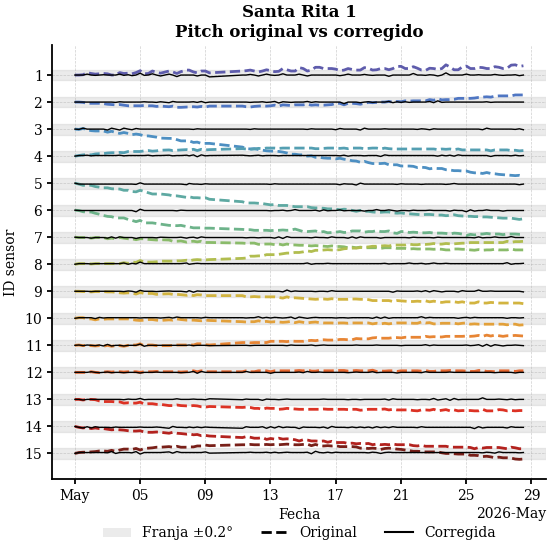

In [12]:
fig = plot_angle_correction_over_time(
    df_corr=df_corr,
    field="pitch",
    depths_m=depths_m,
    valid_sensors=valid_sensors_inc,
    profile_freq=None,
    profile_selection="nearest",
    delta_angle=0.2,
    title=f"{station['name']}\nPitch original vs corregido",
    cmap=cmap,
)

fig.savefig(path2figures / "pitch_correction_over_time.png", dpi=300, bbox_inches="tight", transparent=True)

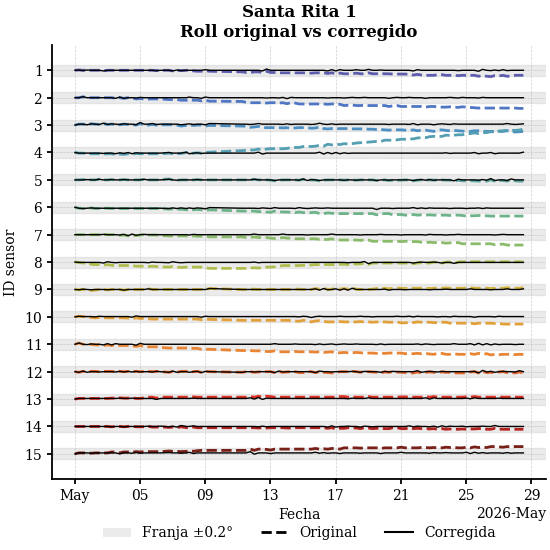

In [13]:
fig = plot_angle_correction_over_time(
    df_corr=df_corr,
    field="roll",
    depths_m=depths_m,
    valid_sensors=valid_sensors_inc,
    profile_freq=None,
    profile_selection="nearest",
    delta_angle=0.2,
    title=f"{station['name']}\nRoll original vs corregido",
    cmap=cmap,
)

fig.savefig(path2figures / "roll_correction_over_time.png", dpi=300, bbox_inches="tight", transparent=True)

## 6. Cálculo de desplazamientos acumulados


In [8]:
df_disp_raw = compute_inclinometer_displacements(
    df=df_corr,
    depths_m=depths_m,
    azimuth_deg=azimuth_deg,
    pitch_col="pitch_deg",
    roll_col="roll_deg",
    timestamp_col="timestamp",
    sensor_col="sensor_id",
    station_col="estacion_id",
    valid_sensors=valid_sensors_inc,
    reference_sensor="deepest",
)

df_disp_corr = compute_inclinometer_displacements(
    df=df_corr,
    depths_m=depths_m,
    azimuth_deg=azimuth_deg,
    pitch_col="pitch_corr_deg",
    roll_col="roll_corr_deg",
    timestamp_col="timestamp",
    sensor_col="sensor_id",
    station_col="estacion_id",
    valid_sensors=valid_sensors_inc,
    reference_sensor="deepest",
)

df_disp_corr[
    [
        "timestamp",
        "sensor_id",
        "depth_m",
        "separation_m",
        "cum_disp_a_mm",
        "cum_disp_b_mm",
        "cum_disp_north_mm",
        "cum_disp_east_mm",
    ]
].head()


,timestamp,sensor_id,depth_m,separation_m,cum_disp_a_mm,cum_disp_b_mm,cum_disp_north_mm,cum_disp_east_mm
0,2026-05-01 00:16:19,10a,10.0,1.0,0.000000,0.000000,0.000000,0.000000
1,2026-05-01 06:16:20,10a,10.0,1.0,-0.003353,-1.192447,0.593320,-1.034365
2,2026-05-01 12:16:20,10a,10.0,1.0,1.199675,-1.002226,1.540062,-0.268116
3,2026-05-01 18:16:21,10a,10.0,1.0,-0.403349,-0.000385,-0.349118,-0.202008
4,2026-05-02 00:16:22,10a,10.0,1.0,0.195014,-0.802446,0.570110,-0.597432


## 7. Gráficas de perfiles acumulados

Puedes usar `components="ab"` para coordenadas locales o `components="ne"` para Norte-Este.


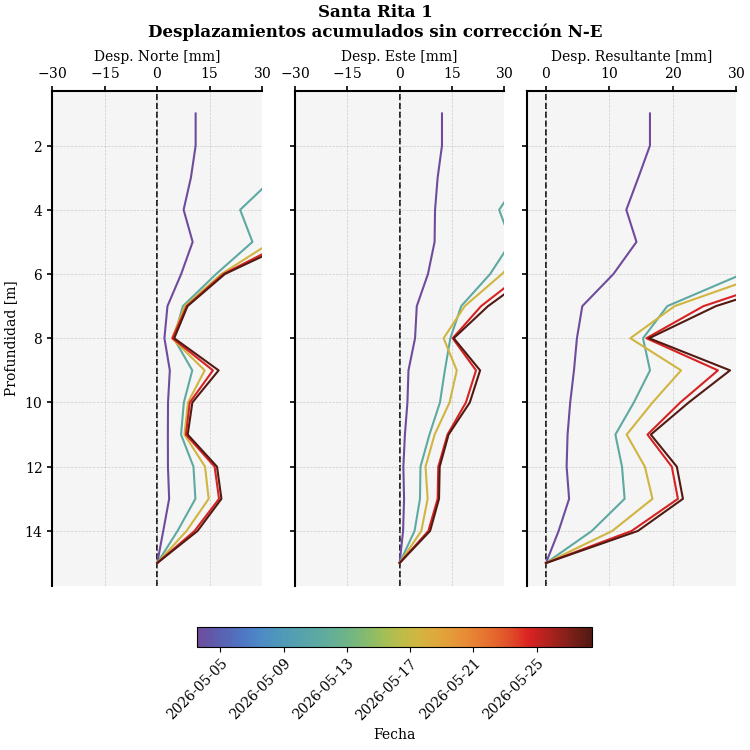

In [9]:
fig = plot_cumulative_displacement_profiles(
    df_disp=df_disp_raw,
    depths_m=depths_m,
    valid_sensors=valid_sensors_inc,
    components="ne",
    profile_freq="7D",
    profile_selection="nearest",
    xlims=(-30, 30),
    title=f"{station['name']}\nDesplazamientos acumulados sin corrección N-E",
    cmap=cmap,
)


fig.savefig(path2figures / "cumulative_displacement_profiles_raw.png", dpi=300, bbox_inches="tight", transparent=True)

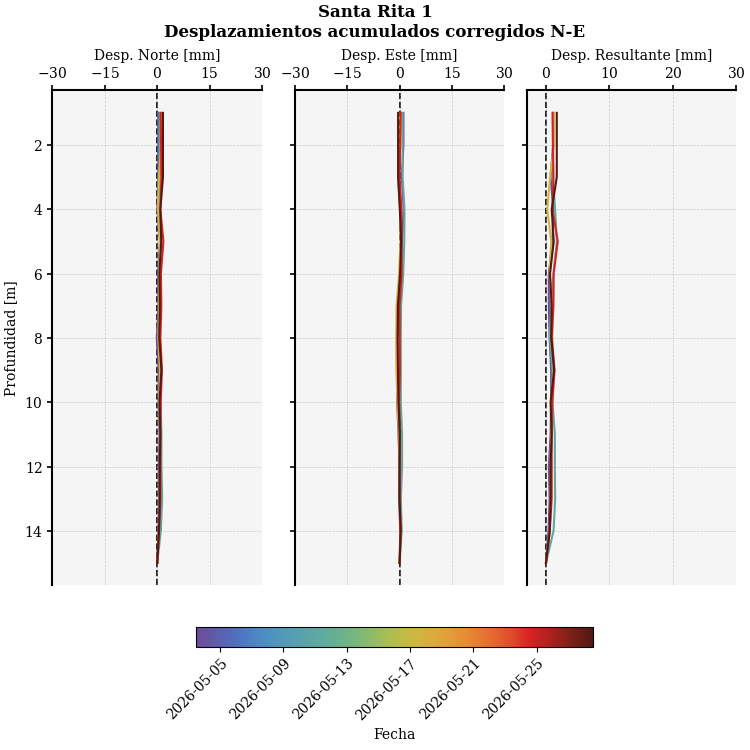

In [10]:
fig = plot_cumulative_displacement_profiles(
    df_disp=df_disp_corr,
    depths_m=depths_m,
    valid_sensors=valid_sensors_inc,
    components="ne",
    profile_freq="7D",
    profile_selection="nearest",
    xlims=(-30, 30),
    title=f"{station['name']}\nDesplazamientos acumulados corregidos N-E",
    cmap=cmap,
)

fig.savefig(path2figures / "cumulative_displacement_profiles_corr.png", dpi=300, bbox_inches="tight", transparent=True)

## 8. Evolución temporal de un sensor específico


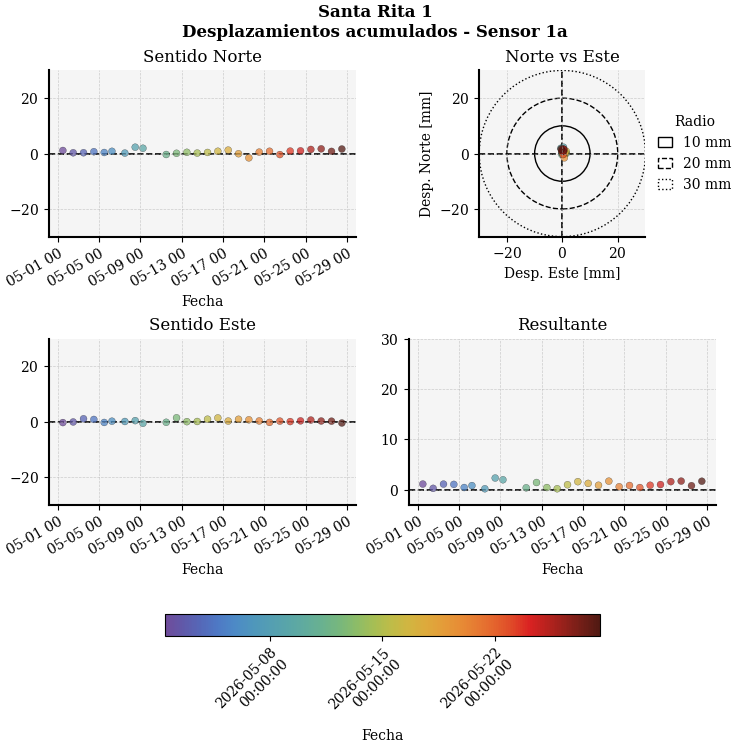

In [11]:
sensor_to_plot = "1a"

fig = plot_sensor_displacement_evolution(
    df_disp=df_disp_corr,
    sensor=sensor_to_plot,
    depths_m=depths_m,
    valid_sensors=valid_sensors_inc,
    components="ne",
    profile_freq="1D",
    profile_selection="nearest",
    ylims=(-30, 30),
    xlims_ab=(-30, 30),
    title=f"{station['name']}\nDesplazamientos acumulados - Sensor {sensor_to_plot}",
    cmap=cmap,
)

fig.savefig(path2figures / f"displacement_evolution_sensor_{sensor_to_plot}.png", dpi=300, bbox_inches="tight", transparent=True)